# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [3]:
!pip install pandas numpy scikit-learn mlflow==2.19.0 matplotlib seaborn jupyter joblib fastapi uvicorn prometheus_client


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip list

Package                            Version
---------------------------------- -----------
alembic                            1.18.4
annotated-doc                      0.0.4
annotated-types                    0.7.0
anyio                              4.13.0
argon2-cffi                        25.1.0
argon2-cffi-bindings               25.1.0
arrow                              1.4.0
asttokens                          3.0.1
async-lru                          2.3.0
attrs                              26.1.0
babel                              2.18.0
beautifulsoup4                     4.14.3
bleach                             6.3.0
blinker                            1.9.0
cachetools                         5.5.2
certifi                            2026.5.20
cffi                               2.0.0
charset-normalizer                 3.4.7
click                              8.4.1
cloudpickle                        3.1.2
colorama                           0.4.6
comm                               0.2

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
print("hello")

hello


In [7]:
print("Python version:")
print(sys.version)

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [8]:
print("\nMLflow version:")
print(mlflow.__version__)


MLflow version:
2.19.0


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [9]:
df = pd.read_csv("../dataset_raw/diabetes.csv")


# **4. Exploratory Data Analysis (EDA)**


Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
print("Informasi dataset:")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

Informasi dataset:
Jumlah baris: 768
Jumlah kolom: 9


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

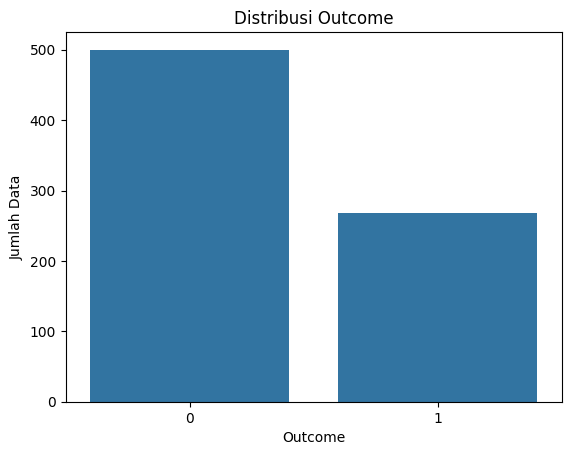

In [17]:
sns.countplot(x="Outcome", data=df)

plt.title("Distribusi Outcome")
plt.xlabel("Outcome")
plt.ylabel("Jumlah Data")

plt.show()

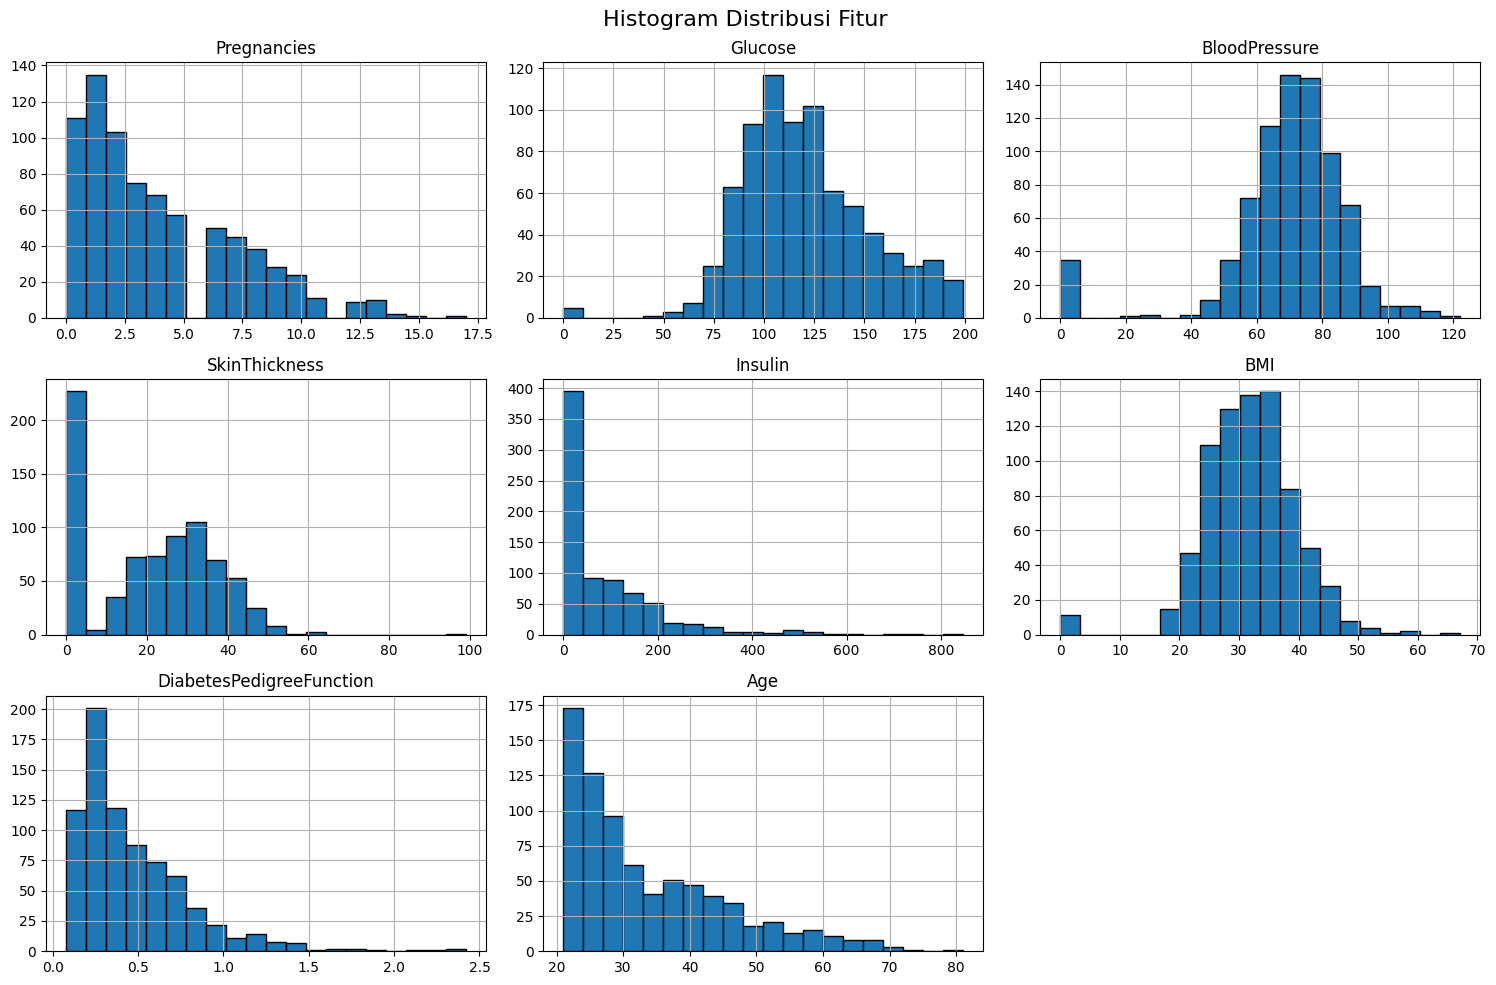

In [18]:
import matplotlib.pyplot as plt

features = df.drop("Outcome", axis=1)

features.hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histogram Distribusi Fitur", fontsize=16)

plt.tight_layout()
plt.show()

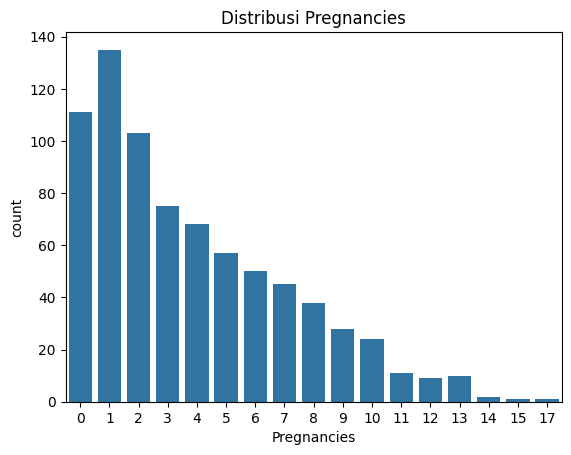

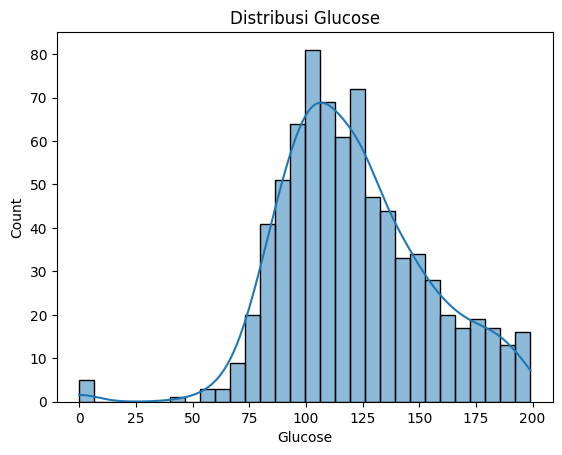

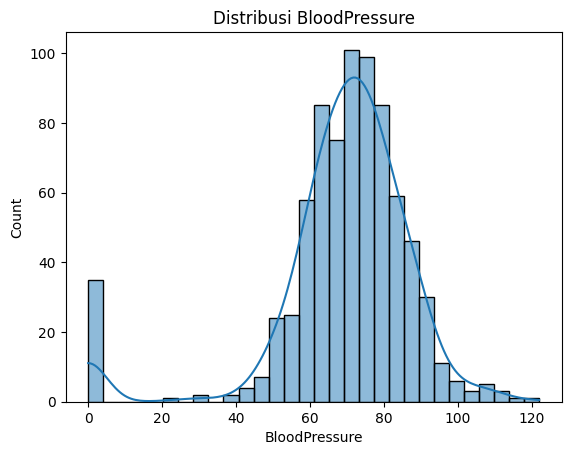

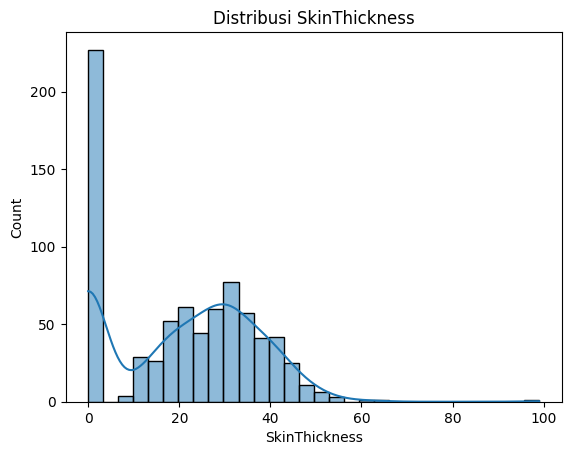

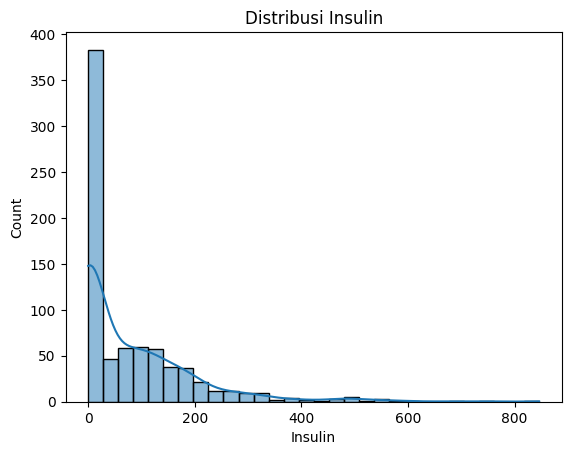

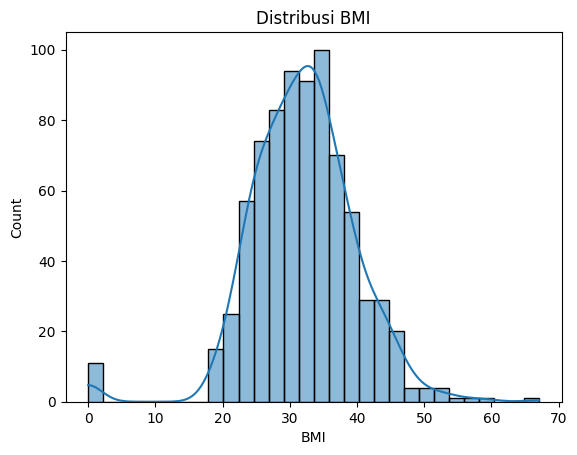

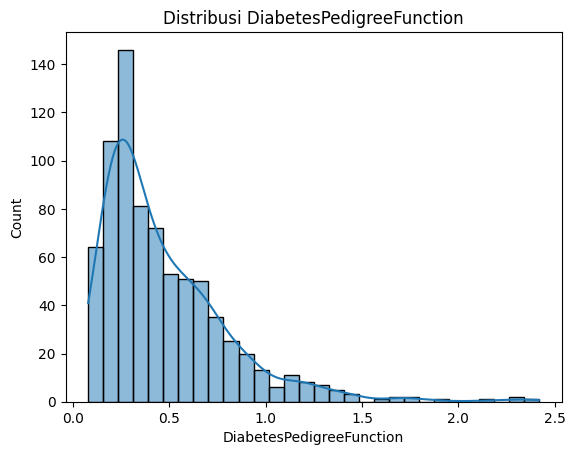

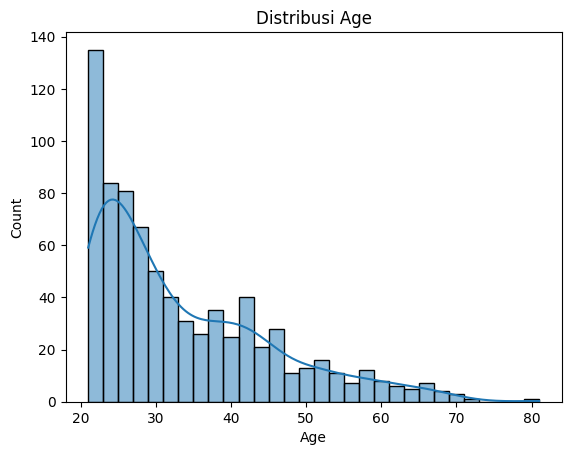

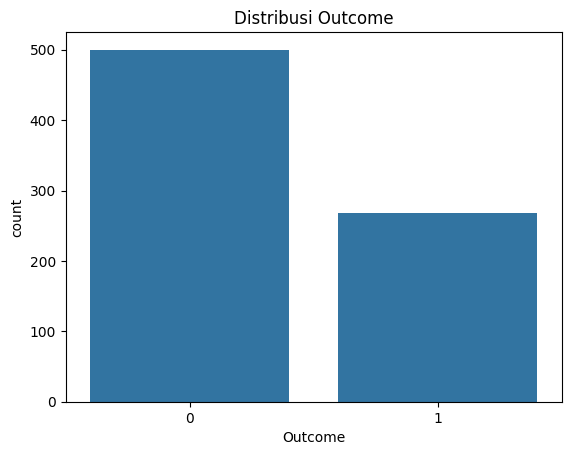

In [19]:
# Histogram Pregnancies
sns.countplot(x="Pregnancies", data=df)
plt.title("Distribusi Pregnancies")
plt.show()

# Histogram Glucose
sns.histplot(df["Glucose"], bins=30, kde=True)
plt.title("Distribusi Glucose")
plt.show()

# Histogram BloodPressure
sns.histplot(df["BloodPressure"], bins=30, kde=True)   
plt.title("Distribusi BloodPressure")
plt.show()

# Histogram SkinThickness
sns.histplot(df["SkinThickness"], bins=30, kde=True)
plt.title("Distribusi SkinThickness")
plt.show()

#Histogram Insulin
sns.histplot(df["Insulin"], bins=30, kde=True)
plt.title("Distribusi Insulin")
plt.show()

# Histogram BMI
sns.histplot(df["BMI"], bins=30, kde=True)
plt.title("Distribusi BMI")
plt.show()

# HIstogram DiabetesPedigreeFunction
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Distribusi DiabetesPedigreeFunction")
plt.show()

# Histogram Age
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribusi Age")
plt.show()

# Histogram Outcome
sns.countplot(x="Outcome", data=df)
plt.title("Distribusi Outcome")
plt.show()


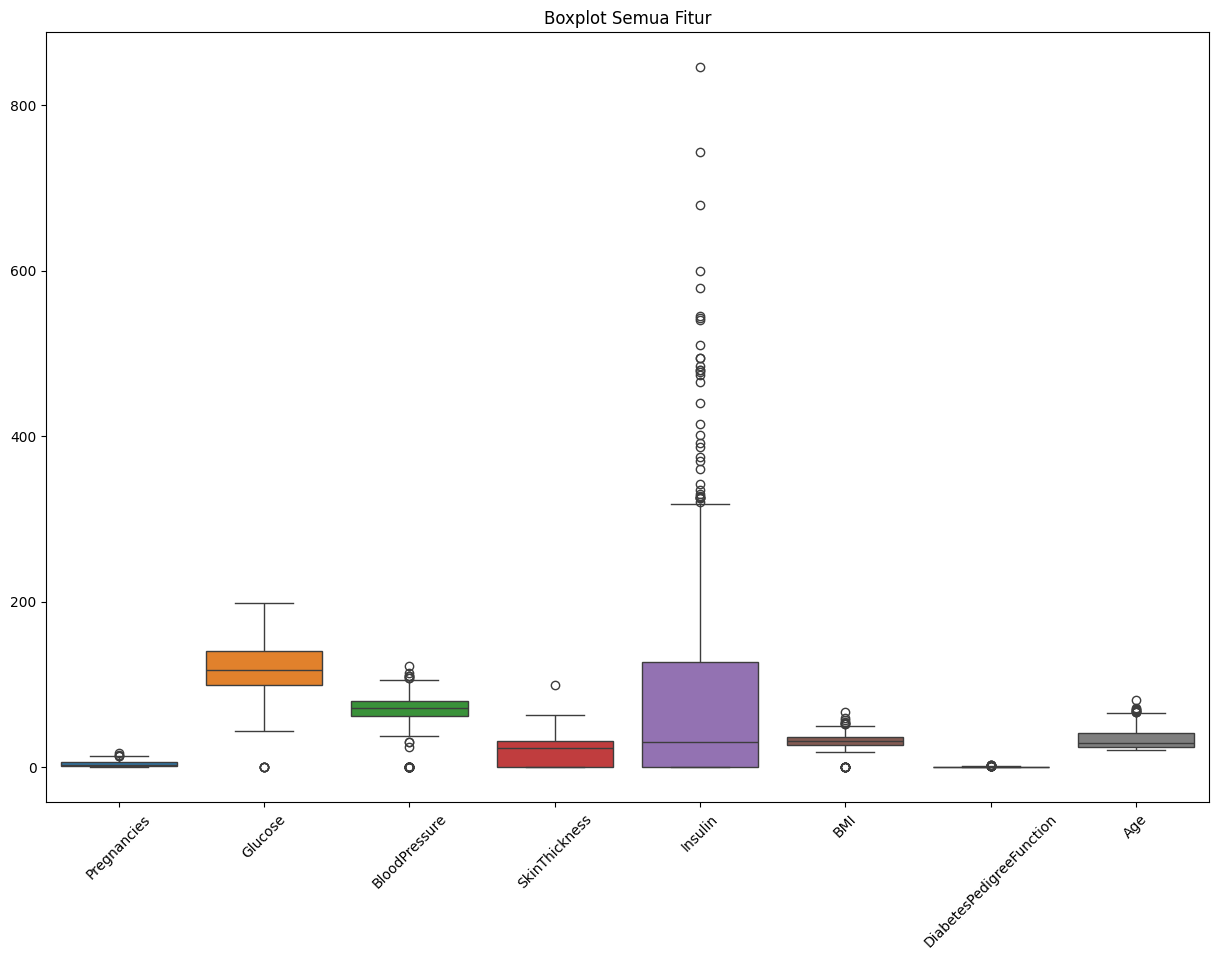

In [20]:
plt.figure(figsize=(15,10))

sns.boxplot(data=features)

plt.xticks(rotation=45)

plt.title("Boxplot Semua Fitur")

plt.show()

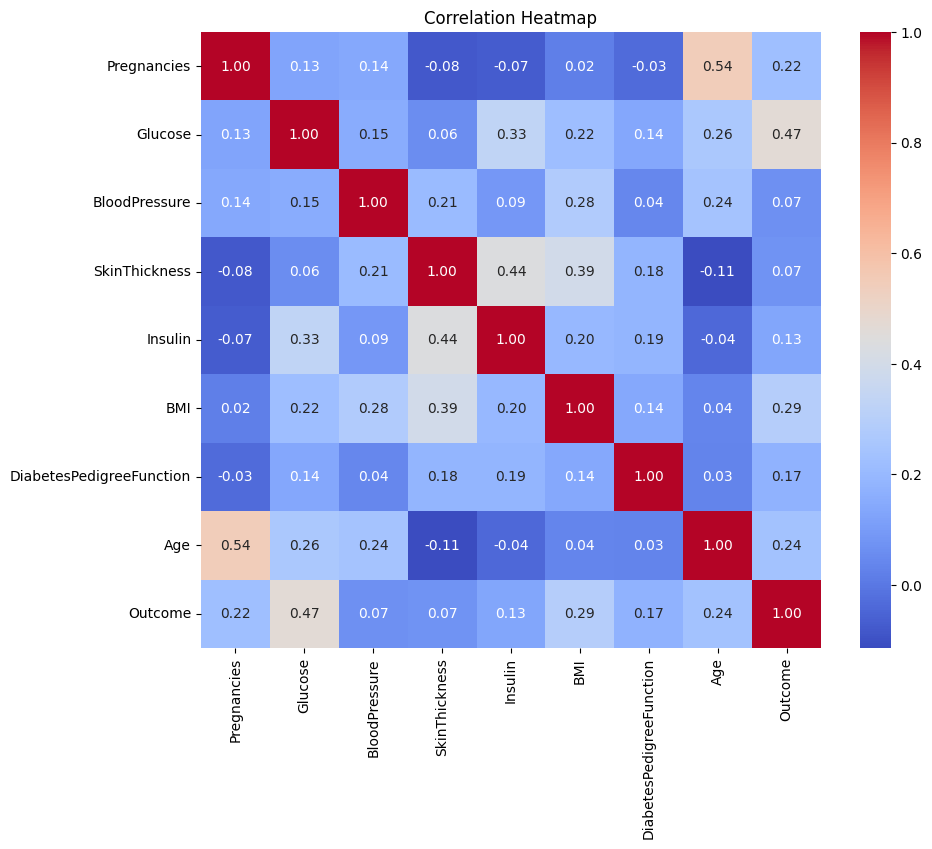

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Berdasarkan Histogram yang ditampilkan terdapat beberapa angka 0 di fitur Glucose, BloodPresure, SkinThickness, Insulin, dan BMI. Jika saya cari referensi di Google, sepertinya tidak mungkin apabila nilai pada fitur ini pada angka 0. Misalnya, tidak mungkin ada manusia dengan kadar Glukosa 0, tekanan darah 0, ketebalan kulit 0, insulin 0 dan Body Mass Index 0. Jadi ini merupakan missing value sehingga diisi dengan angka 0. 

In [22]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Jumlah nilai 0 pada setiap kolom:")

for col in columns_with_zero:
    print(f"{col}: {(df[col] == 0).sum()}")

Jumlah nilai 0 pada setiap kolom:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


### Insight Dataset

1. Dataset terdiri dari 768 baris dan 9 kolom yang mencakup fitur medis serta target klasifikasi diabetes.

2. Tidak ditemukan missing value pada dataset. Namun, ditemukan beberapa nilai 0 yang tidak realistis secara medis pada fitur Glucose, BloodPressure, SkinThickness, Insulin, dan BMI.

3. Nilai 0 pada fitur medis tersebut dianggap sebagai pseudo missing value dan akan ditangani dengan mengganti nilai 0 menggunakan median dari masing-masing fitur.

4. Distribusi target menunjukkan jumlah data non-diabetes lebih banyak dibandingkan data diabetes, namun perbedaannya masih dalam batas yang dapat diterima untuk klasifikasi.

5. Berdasarkan histogram distribusi fitur, beberapa fitur seperti Insulin dan DiabetesPedigreeFunction memiliki distribusi yang cenderung skewed.

6. Boxplot menunjukkan adanya beberapa outlier pada fitur Insulin, BMI, dan SkinThickness. Outlier masih dipertahankan pada eksperimen awal karena masih memungkinkan memiliki makna medis.

7. Heatmap korelasi menunjukkan bahwa fitur Glucose, BMI, dan Age memiliki hubungan positif yang cukup kuat terhadap Outcome (diabetes).

8. Tidak ditemukan multikolinearitas yang sangat tinggi antar fitur sehingga seluruh fitur masih dipertahankan untuk proses modelling.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [23]:
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in columns_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


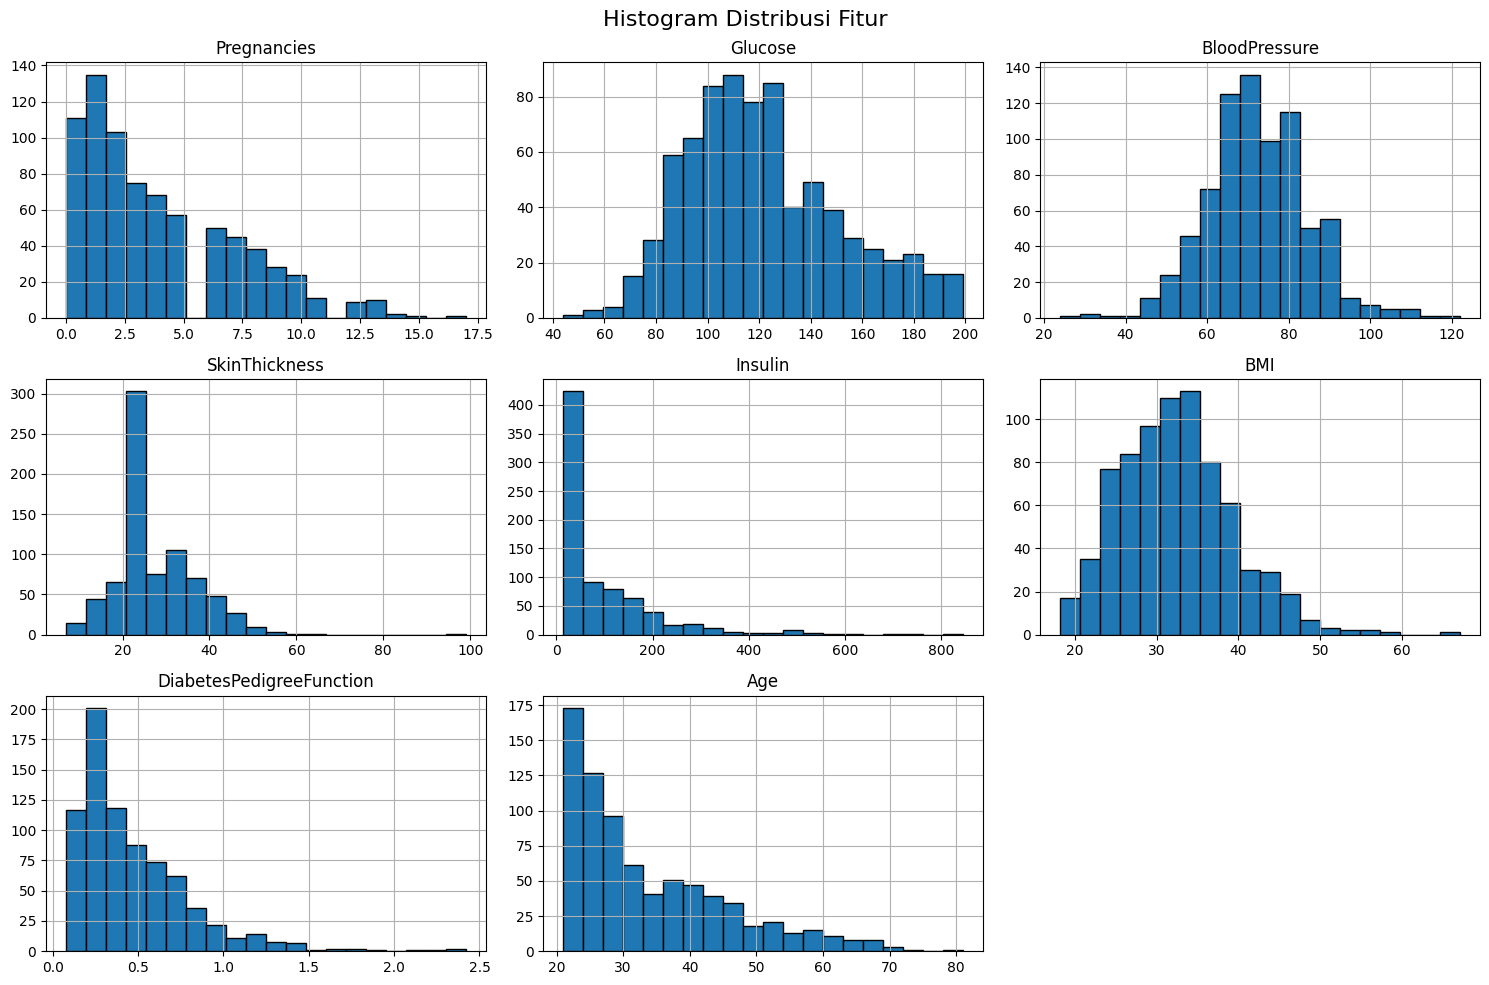

In [25]:
import matplotlib.pyplot as plt

features = df.drop("Outcome", axis=1)

features.hist(
    figsize=(15,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histogram Distribusi Fitur", fontsize=16)

plt.tight_layout()
plt.show()

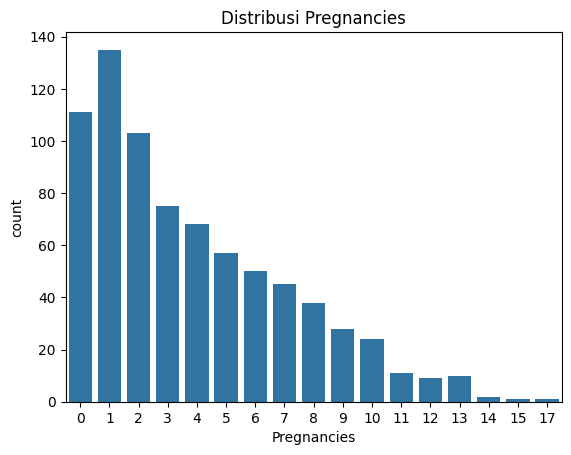

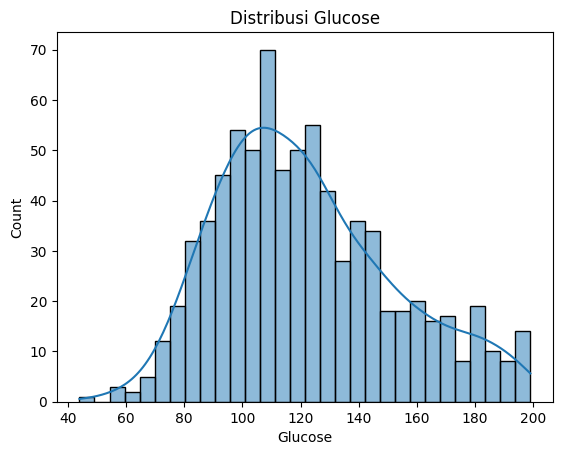

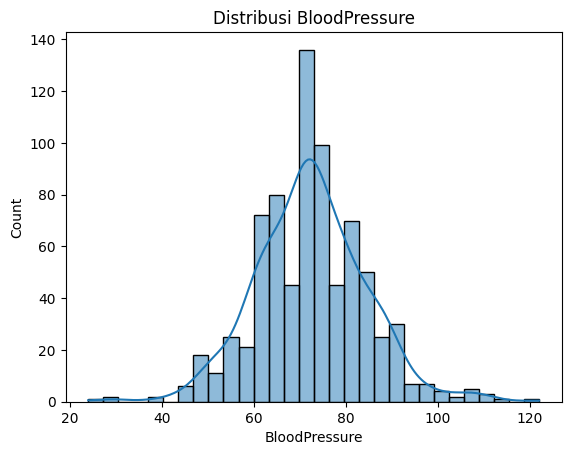

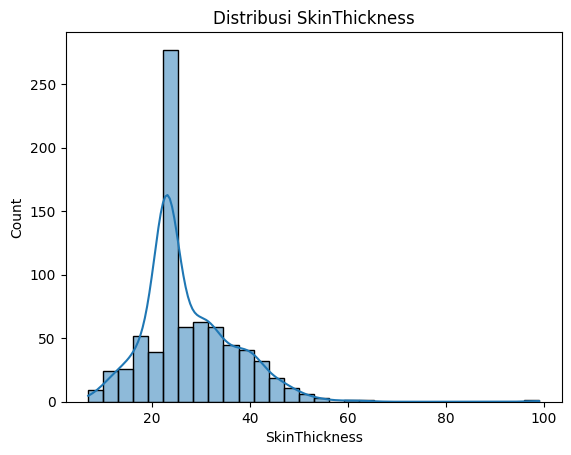

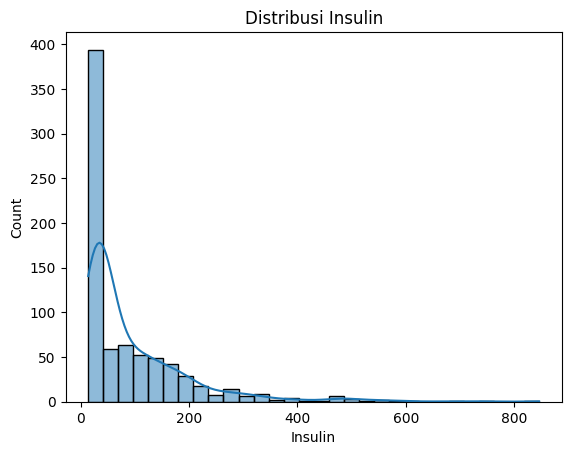

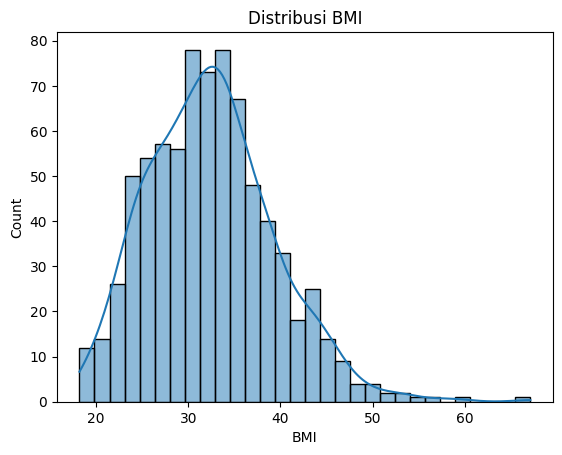

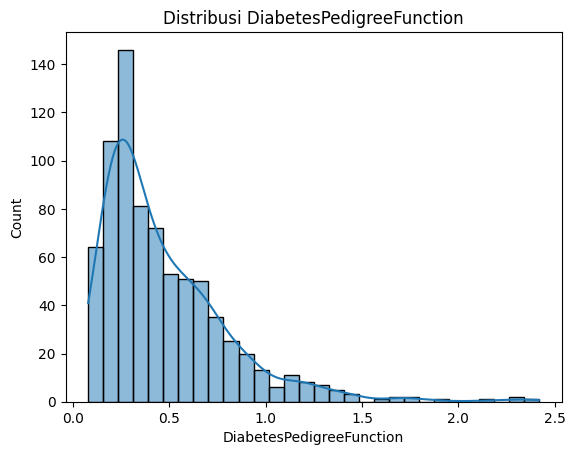

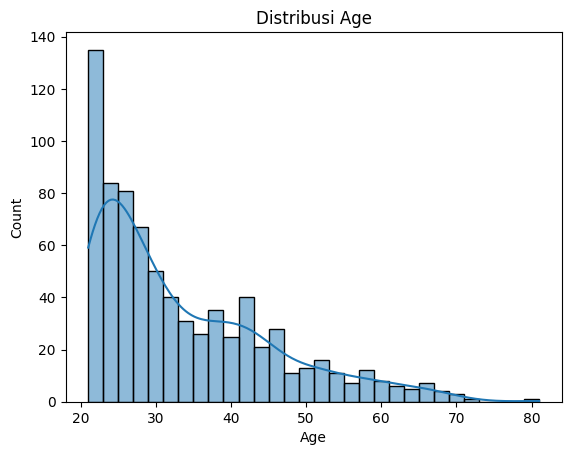

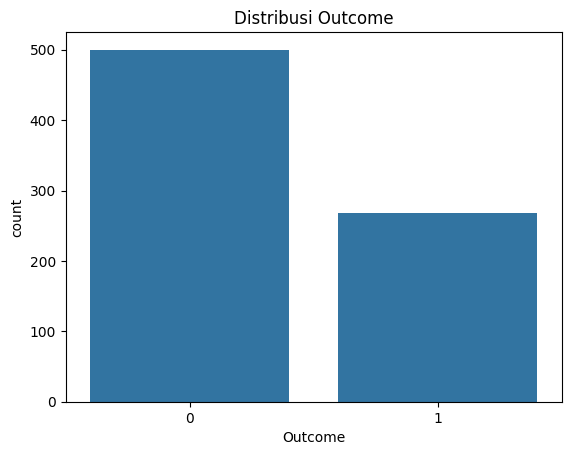

In [26]:
# Histogram Pregnancies
sns.countplot(x="Pregnancies", data=df)
plt.title("Distribusi Pregnancies")
plt.show()

# Histogram Glucose
sns.histplot(df["Glucose"], bins=30, kde=True)
plt.title("Distribusi Glucose")
plt.show()

# Histogram BloodPressure
sns.histplot(df["BloodPressure"], bins=30, kde=True)   
plt.title("Distribusi BloodPressure")
plt.show()

# Histogram SkinThickness
sns.histplot(df["SkinThickness"], bins=30, kde=True)
plt.title("Distribusi SkinThickness")
plt.show()

#Histogram Insulin
sns.histplot(df["Insulin"], bins=30, kde=True)
plt.title("Distribusi Insulin")
plt.show()

# Histogram BMI
sns.histplot(df["BMI"], bins=30, kde=True)
plt.title("Distribusi BMI")
plt.show()

# HIstogram DiabetesPedigreeFunction
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Distribusi DiabetesPedigreeFunction")
plt.show()

# Histogram Age
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribusi Age")
plt.show()

# Histogram Outcome
sns.countplot(x="Outcome", data=df)
plt.title("Distribusi Outcome")
plt.show()


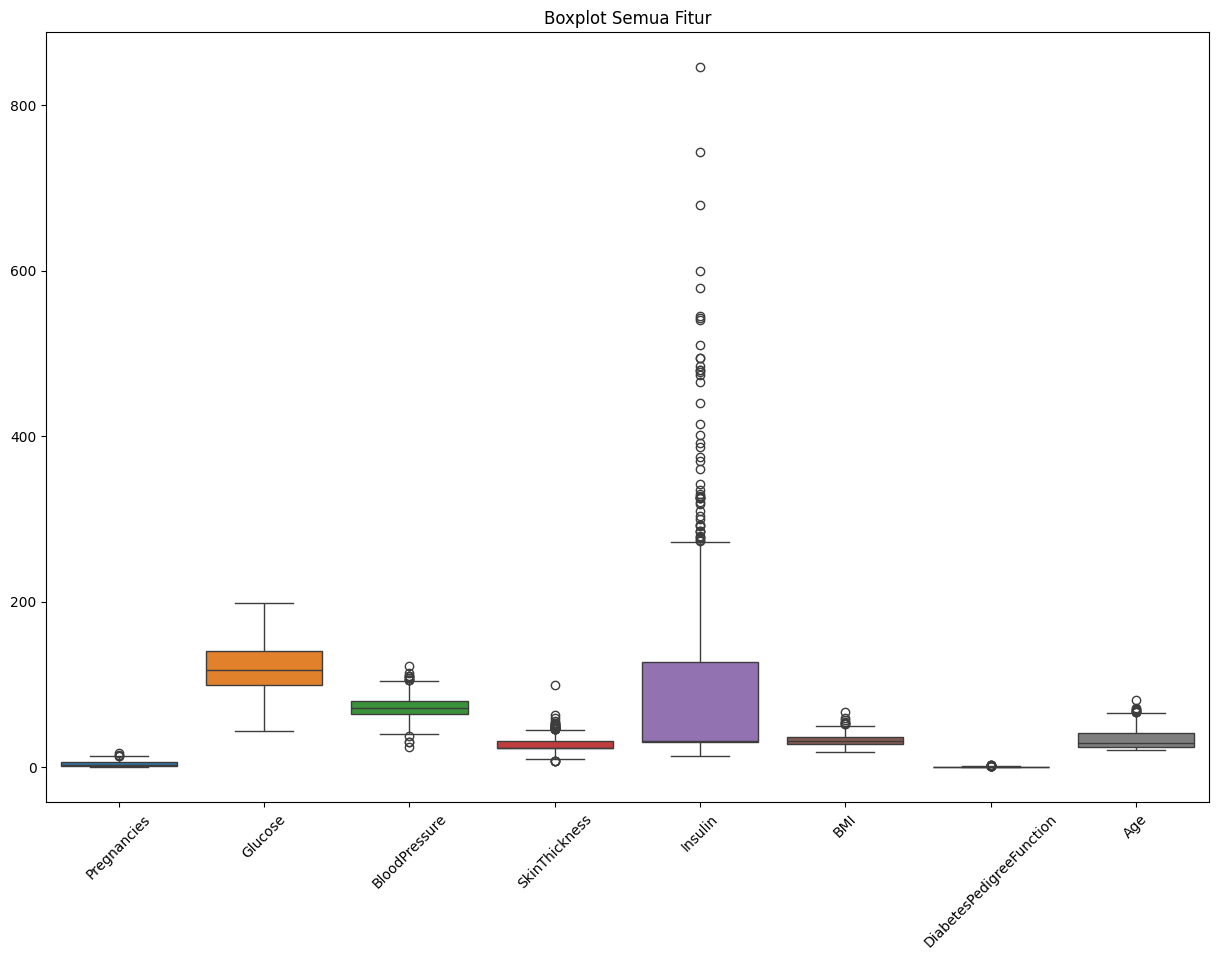

In [27]:
plt.figure(figsize=(15,10))

sns.boxplot(data=features)

plt.xticks(rotation=45)

plt.title("Boxplot Semua Fitur")

plt.show()

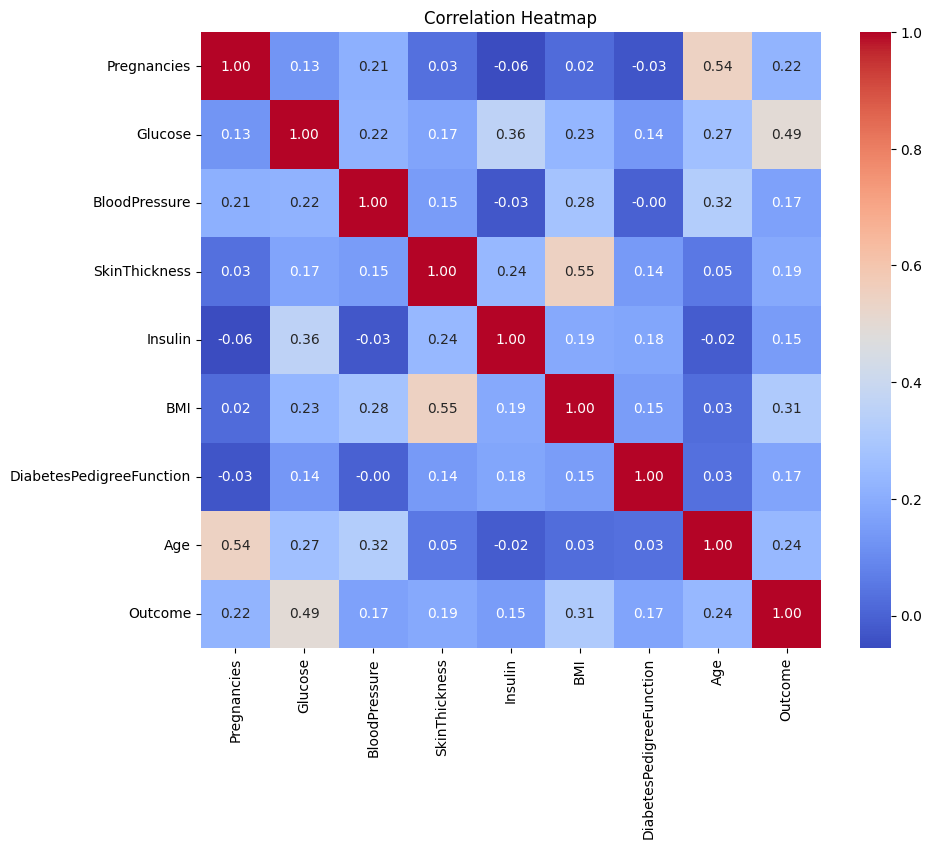

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
df.head(50)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
5,5,116,74,23,30.5,25.6,0.201,30,0
6,3,78,50,32,88.0,31.0,0.248,26,1
7,10,115,72,23,30.5,35.3,0.134,29,0
8,2,197,70,45,543.0,30.5,0.158,53,1
9,8,125,96,23,30.5,32.0,0.232,54,1


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import os

output_dir = "diabetes_preprocessing"

os.makedirs(output_dir, exist_ok=True)

In [ ]:
train_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

train_df["Outcome"] = y_train.values


test_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

test_df["Outcome"] = y_test.values


In [ ]:
train_df.to_csv(
    f"{output_dir}/train.csv",
    index=False
)

test_df.to_csv(
    f"{output_dir}/test.csv",
    index=False
)

print("Dataset preprocessing berhasil disimpan.")

Dataset preprocessing berhasil disimpan.


In [ ]:
duplicate_dir = "../../Membangun model/diabetes_preprocessing"

train_df.to_csv(
    f"{duplicate_dir}/train.csv",
    index=False
)

test_df.to_csv(
    f"{duplicate_dir}/test.csv",
    index=False
)

print("Dataset preprocessing berhasil disimpan di folder ../../Membangun model/diabetes_preprocessing.")

Dataset preprocessing berhasil disimpan di folder ../../Membangun model/diabetes_preprocessing.


In [ ]:
print(os.listdir(output_dir))

['test.csv', 'train.csv']


Berdasarkan hasil Exploratory Data Analysis (EDA), dilakukan beberapa tahapan preprocessing sebagai berikut:

1. Nilai 0 yang tidak realistis secara medis pada fitur Glucose, BloodPressure, SkinThickness, Insulin, dan BMI ditangani menggunakan median replacement.

2. Dataset dipisahkan menjadi fitur (X) dan target (y), dengan target berupa kolom Outcome.

3. Dataset dibagi menjadi data training dan data testing menggunakan train_test_split dengan proporsi 80:20.

4. Fitur numerik dilakukan standarisasi menggunakan StandardScaler untuk menyamakan skala antar fitur dan membantu performa model machine learning.

5. Dataset hasil preprocessing disimpan menjadi train.csv dan test.csv untuk digunakan pada tahap modelling berikutnya.